In [56]:
"""spectral analysis(colormaster alpha 1.0)"""
"""By Matija Breljak"""
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from colorist import ColorRGB

Pipeline=[]
LightSource=[]
FilmList=pd.read_csv("Film-List.csv")
ElementList=pd.read_csv("Element_List.csv")
SmpList=pd.read_csv("Sample-List.csv")
method=0 #default is 0 for averaging exposure(other values will be added for median, log and other possible methods)
##defs
def PdtoA(PDin, x):
  return np.array(PDin.iloc[:, x])
def IntegrateChannel(Channel):
  z=0
  x, y = PdtoA(Channel, 0), PdtoA(Channel, 1)
  for i in range(len(x)-1):
    if np.isnan(y[i]) or np.isnan(y[i+1]):
      continue
    else:
      z+=(x[i+1]-x[i])*(y[i]+y[i+1])/2
  return z
def CalculateColorRGB(InSp3, InSp3W):
  chan = lambda df: [IntegrateChannel(df.iloc[:, i:i+2]) for i in (0, 2, 4)]
  R, G, B = chan(InSp3)
  W = max(chan(InSp3W))
  return ColorRGB(int(255*R/W), int(255*G/W), int(255*B/W))
def CalculateExposureLoss(sp1, sp2):
  chan = lambda df: [IntegrateChannel(df.iloc[:, i:i+2]) for i in (0, 2, 4)]
  losses = [np.log2(a / (0.0001 + b)) for a, b in zip(chan(sp1), chan(sp2))]
  return (*losses, np.average(losses))
def ApplyFilter(InSp,Element):
  x_coords, y_coords = PdtoA(InSp, 0) , PdtoA(InSp, 1)
  filter_x, filter_y = PdtoA(Element, 0), PdtoA(Element, 1)
  interpolated_filter = np.interp(x_coords, filter_x, filter_y)
  return pd.DataFrame({"x": x_coords.tolist(), "y": (y_coords * interpolated_filter).tolist()})
def ApplyPipeline(InSp,Pipeline):
  for i in range(len(Pipeline)):
    InSp=ApplyFilter(InSp,Pipeline[i])
  return InSp
def FilterFilm(InSp3, Pipeline):
  chan = lambda df: [ApplyPipeline(df.iloc[:, i:i+2], Pipeline) for i in (0, 2, 4)]
  return pack(*chan(InSp3))
def pack(InSp1, InSp2, InSp3):
  xc, yc, xm, ym, xy, yy = PdtoA(InSp1, 0), PdtoA(InSp1, 1), PdtoA(InSp2, 0), PdtoA(InSp2, 1), PdtoA(InSp3, 0), PdtoA(InSp3, 1)
  return pd.DataFrame({ "xc": xc, "yc": yc, "xm": xm, "ym": ym, "xy": xy, "yy":yy})
def CorrectSpectrumAVG(InSp3):
  InSp3 = InSp3.copy()
  chan = lambda df: [IntegrateChannel(df.iloc[:, i:i+2]) for i in (0, 2, 4)]
  R, G, B = chan(InSp3)
  T = np.average([R, G, B])
  InSp3.iloc[:, [1, 3, 5]] = InSp3.iloc[:, [1, 3, 5]] * (T / np.array([R, G, B]))
  return InSp3
def ApplySampleSP(InSp3, SampleSP):
  chan = lambda df: [ApplyFilter(df.iloc[:, i:i+2], SampleSP) for i in (0, 2, 4)]
  return pack(*chan(InSp3))
def GenerateLightSource(T): #Abs crno telo
  x = np.arange(350, 801, 1)
  y = 1/((x**5)*np.expm1(1.4388e7/(x*T)))
  y = y/np.max(y)
  return pd.DataFrame({"x": x, "y": y})

def InputReportToTextFile(Pipeline):
  with open("InputReport.txt", "w") as f:
    f.write("Pipeline:\n")
    for i, element in enumerate(Pipeline):
      f.write(f"Element {i+1}:\n")
      f.write(element.to_string(index=False))
      f.write("\n\n")


In [57]:
print("choose film")
print(FilmList)
Film=pd.read_csv(str(FilmList.iloc[int(input("Film number: "))-1,1]))
Film.iloc[:, [1, 3, 5]] = 10 ** Film.iloc[:, [1, 3, 5]] #linearization
e=0

while(e!=-2):
  print("choose filters/elements (enter -1 if you finnished with adding filters)")
  print(ElementList.to_string(index=False))
  e=int(input("Filter number: "))-1
  if e == -2:
    break
  Pipeline.append(pd.read_csv(str(ElementList.iloc[e,1])))
print("choose test sample")
print(SmpList)
TestSmp=pd.read_csv(str(SmpList.iloc[int(input("Test sample number: "))-1,1]))
print("only white correction method avaliable is average")
T = input("Set light source temperature in kelvins (default is 2856K): ")
if T == "":
  T = 2856
else:
  T = float(T)
Light = GenerateLightSource(T)




choose film
   x                          y
0  1  Kodak-Portra-800-data.csv
choose filters/elements (enter -1 if you finnished with adding filters)
 x              y
 1 KB-12-data.csv
 2 KR-12-data.csv
 3  CC40-data.csv
choose filters/elements (enter -1 if you finnished with adding filters)
 x              y
 1 KB-12-data.csv
 2 KR-12-data.csv
 3  CC40-data.csv
choose test sample
   x                           y
0  1  LEAF-REFLECTANCE2-data.csv
only white correction method avaliable is average


In [58]:
InputReportToTextFile(Pipeline)


plotting spectra
light source spectrum


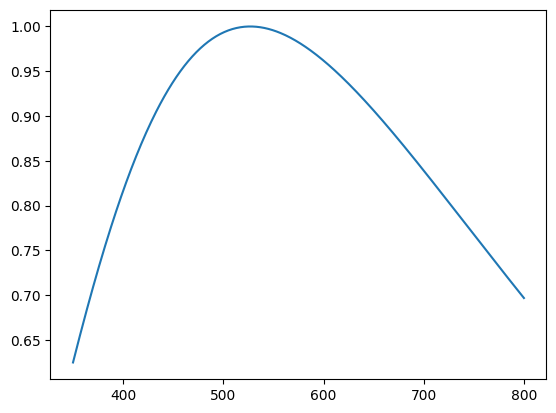

true film spectrum


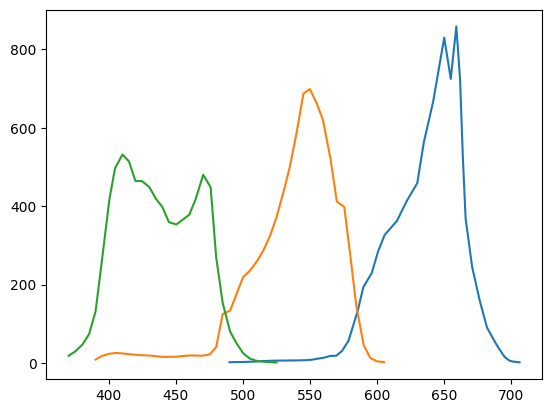

true film spectrum + filters


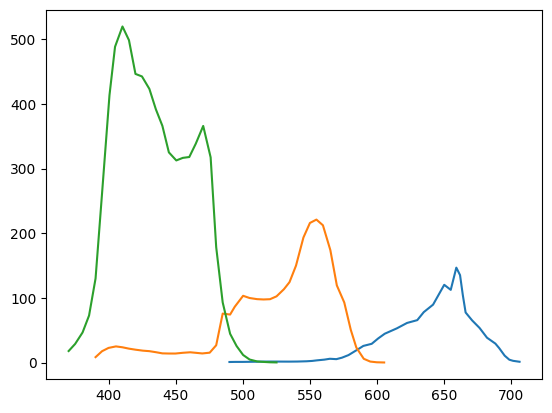

compiled film spectrum + filters


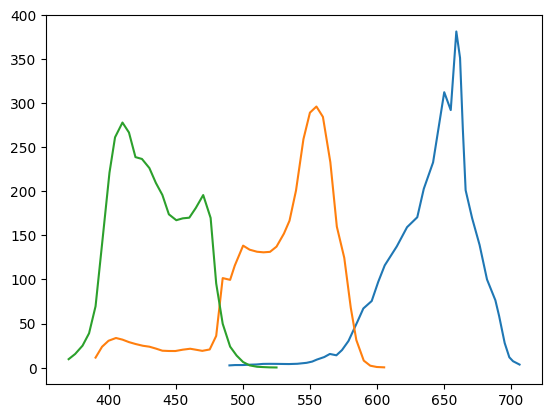

compiled film spectrum + filters + sample


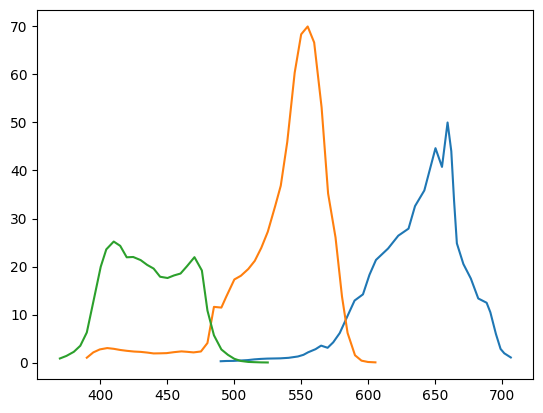

COLOR ANALYSIS:
true white of the film ▉
true white + filters ▉
true sample color ▉
true sample color + filters ▉
post correction sample ▉
post correction sample + filters ▉
true exposure loss  (np.float64(2.5727889936602977), np.float64(1.5625237703983126), np.float64(0.17396565624900934), np.float64(1.43642614010254))


In [59]:
WTrue = CalculateColorRGB(Film,Film)
WTrueF = CalculateColorRGB(FilterFilm(Film,Pipeline),FilterFilm(Film,Pipeline))
STrue = CalculateColorRGB(ApplySampleSP(Film, TestSmp),Film)
STrueF = CalculateColorRGB(ApplySampleSP(FilterFilm(Film, Pipeline), TestSmp),Film)
SPost = CalculateColorRGB(ApplySampleSP(CorrectSpectrumAVG(Film), TestSmp),CorrectSpectrumAVG(Film))
SPostF = CalculateColorRGB(ApplySampleSP(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), TestSmp),CorrectSpectrumAVG(FilterFilm(Film, Pipeline)))
ELossT = CalculateExposureLoss(Film, FilterFilm(Film, Pipeline))

print("plotting spectra")
print("light source spectrum")
plt.plot(PdtoA(Light, 0), PdtoA(Light, 1), label="LightSource")
plt.show()
print("true film spectrum")
plt.plot(PdtoA(Film, 0), PdtoA(Film, 1), label="FilmR")
plt.plot(PdtoA(Film, 2), PdtoA(Film, 3), label="FilmG")
plt.plot(PdtoA(Film, 4), PdtoA(Film, 5), label="FilmB")
plt.show()
print("true film spectrum + filters")
plt.plot(PdtoA(FilterFilm(Film,Pipeline), 0), PdtoA(FilterFilm(Film,Pipeline), 1), label="FilmR")
plt.plot(PdtoA(FilterFilm(Film,Pipeline), 2), PdtoA(FilterFilm(Film,Pipeline), 3), label="FilmG")
plt.plot(PdtoA(FilterFilm(Film,Pipeline), 4), PdtoA(FilterFilm(Film,Pipeline), 5), label="FilmB")
plt.show()
print("compiled film spectrum + filters")
plt.plot(PdtoA(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), 0), PdtoA(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), 1), label="FilmR")
plt.plot(PdtoA(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), 2), PdtoA(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), 3), label="FilmG")
plt.plot(PdtoA(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), 4), PdtoA(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), 5), label="FilmB")
plt.show()
print("compiled film spectrum + filters + sample")
plt.plot(PdtoA(ApplySampleSP(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), TestSmp), 0), PdtoA(ApplySampleSP(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), TestSmp), 1), label="FilmR")
plt.plot(PdtoA(ApplySampleSP(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), TestSmp), 2), PdtoA(ApplySampleSP(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), TestSmp), 3), label="FilmG")
plt.plot(PdtoA(ApplySampleSP(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), TestSmp), 4), PdtoA(ApplySampleSP(CorrectSpectrumAVG(FilterFilm(Film,Pipeline)), TestSmp), 5), label="FilmB")
plt.show()


print("COLOR ANALYSIS:")
print(f"true white of the film {WTrue}▉{ColorRGB.OFF}")
print(f"true white + filters {WTrueF}▉{ColorRGB.OFF}")
print(f"true sample color {STrue}▉{ColorRGB.OFF}")
print(f"true sample color + filters {STrueF}▉{ColorRGB.OFF}")
print(f"post correction sample {SPost}▉{ColorRGB.OFF}")
print(f"post correction sample + filters {SPostF}▉{ColorRGB.OFF}")
print("true exposure loss ",ELossT)